# Lens 1: Speed Safety Assessment
Scores each road segment based on how far observed speeds exceed safe thresholds, weighted by traffic volume. Higher score = greater speed-related safety risk.

In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import folium
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

In [2]:
thai_gdf = gpd.read_file('data/thai_clean_gdf.geojson')
india_gdf = gpd.read_file('data/india_clean_gdf.geojson')

print(f"Thailand: {thai_gdf.shape} | India: {india_gdf.shape}")

Thailand: (11134, 19) | India: (3577, 17)


## Feature Engineering

Three raw gap metrics are derived from the observed speed data. Each is **clipped at zero** so that segments where drivers are travelling below the limit contribute zero risk — only exceedances matter.

| Feature | Formula | What it captures |
|---|---|---|
| `f85LimitGap` | F85th speed − Speed Limit | How fast the fastest 15% of drivers go relative to the posted limit. This is the primary over-speed signal used in road safety research. |
| `MedianLimitGap` | Median speed − Speed Limit | Whether *typical* traffic, not just outliers, is routinely exceeding the limit. A positive value means speeding is systemic. |
| `SpeedSpread` | F85th speed − Median speed | The dispersion of speeds on the road. High spread means a wide mix of fast and slow drivers — a known crash risk factor independent of absolute speed. |

> **Why clip at zero?** A road where F85 = 45 km/h and the limit is 60 km/h is not safer than one where both are equal — but it carries no *excess speed risk*. Clipping prevents negative values from suppressing the scores of genuinely risky neighbours during normalisation.

In [3]:
def add_gap_features(gdf):
    gdf = gdf.copy()
    gdf['f85LimitGap']    = gdf['F85thPercentileSpeed'] - gdf['SpeedLimit']
    gdf['MedianLimitGap'] = gdf['MedianSpeed']          - gdf['SpeedLimit']
    gdf['SpeedSpread']    = gdf['F85thPercentileSpeed'] - gdf['MedianSpeed']
    return gdf

thai_gdf  = add_gap_features(thai_gdf)
india_gdf = add_gap_features(india_gdf)

## Safe Speed Thresholds

Speed limits are set by local authorities and can be permissive, outdated, or inconsistently enforced. To anchor the scoring in evidence-based safety science rather than posted limits alone, each road segment is assigned a **Safe System threshold** drawn from the World Bank R4L Framework (Turner et al. 2024, *Guide for Safe Speeds*).

The threshold is looked up by `(RoadClass, LandUse)` — e.g. a rural primary road has a safe threshold of 80 km/h, while an urban primary road is 50 km/h. Each entry also carries a `MinPlausible` / `MaxPlausible` range used to flag segments where the posted limit itself looks suspect (e.g. 10 km/h on a motorway, or 140 km/h on a secondary urban street).

**Derived flags:**
- `SpeedLimitPlausible` — boolean; False if the posted limit falls outside the plausible range for that road type
- `PlausibilityFlag` — `"Plausible"`, `"Limit Suspect"` (too low), `"Limit Too High"`, or `"Unknown"` (unrecognised road class)
- `F85ExceedsSafeThreshold` — True if the 85th-percentile speed exceeds the safe threshold (not just the posted limit)
- `MedianExceedsSafeThreshold` — True if the median speed exceeds the safe threshold

> Using the safe threshold rather than the posted limit means a segment posted at 90 km/h on a rural primary (safe threshold = 80 km/h) will trigger the exceedance flag even if drivers are "obeying" the limit. This is intentional: the scoring reflects biomechanical crash survivability, not regulatory compliance.

In [4]:
# (RoadClass, LandUse): (min_plausible, safe_threshold, max_plausible)
safe_system = {
    ('motorway', 'RURAL'):    (80,  100, 120),
    ('motorway', 'URBAN'):    (60,   80, 100),
    ('trunk',    'RURAL'):    (60,   80, 100),
    ('trunk',    'URBAN'):    (40,   60,  80),
    ('primary',  'RURAL'):    (50,   80,  90),
    ('primary',  'URBAN'):    (30,   50,  60),
    ('secondary','RURAL'):    (40,   60,  80),
    ('secondary','URBAN'):    (20,   50,  60),
}

def apply_safe_system(gdf):
    gdf = gdf.copy()
    gdf[['MinPlausible', 'SafeThreshold', 'MaxPlausible']] = gdf.apply(
        lambda row: pd.Series(
            safe_system.get((row['RoadClass'], row['LandUse']), (None, None, None))
        ), axis=1
    )

    def classify_plausibility(row):
        if pd.isna(row['SpeedLimit']) or pd.isna(row['MinPlausible']):
            return 'Unknown'
        elif row['SpeedLimit'] < row['MinPlausible']:
            return 'Limit Suspect'
        elif row['SpeedLimit'] > row['MaxPlausible']:
            return 'Limit Too High'
        return 'Plausible'

    gdf['SpeedLimitPlausible'] = (
        (gdf['SpeedLimit'] >= gdf['MinPlausible']) &
        (gdf['SpeedLimit'] <= gdf['MaxPlausible'])
    )
    gdf['PlausibilityFlag'] = gdf.apply(classify_plausibility, axis=1)
    gdf['F85ExceedsSafeThreshold']    = gdf['F85thPercentileSpeed'] > gdf['SafeThreshold']
    gdf['MedianExceedsSafeThreshold'] = gdf['MedianSpeed']          > gdf['SafeThreshold']
    return gdf

thai_gdf  = apply_safe_system(thai_gdf)
india_gdf = apply_safe_system(india_gdf)

## Score Calculation

The final `SpeedSafetyScore` is built in three steps.

---

### Step 1 — Normalise inputs

- The three gap metrics are clipped at zero (see Feature Engineering above) to remove negative values.
- `WeightedSample` (traffic volume) is **log-transformed** with `log1p` before normalising. Traffic counts are heavily right-skewed — a handful of major corridors have enormously higher counts than most roads. Log-transforming compresses that tail so high-volume roads don't completely dominate the score; the volume signal still matters, it just scales more reasonably.
- All four values are then **min-max normalised to [0, 1]** within each country so they can be combined on a common scale.

---

### Step 2 — Build the Speed Component

Five sub-signals are combined into a single `SpeedComponent` using weights derived from the World Bank R4L Framework:

| Signal | Weight | Rationale |
|---|---|---|
| `F85ExceedsSafeThreshold` | **0.25** | Strongest binary signal — the 85th-percentile driver is above the biomechanically safe speed |
| `MedianExceedsSafeThreshold` | **0.25** | Confirms the problem is systemic, not just a fast-tail outlier |
| `NormMedianLimitGap` | **0.20** | Continuous magnitude of how far typical traffic is over the limit |
| `NormF85LimitGap` | **0.15** | Continuous magnitude of the 85th-percentile excess |
| `NormSpeedSpread` | **0.15** | Speed inconsistency; a wide spread between fast and slow drivers increases crash risk |

The two binary flags collectively carry 50% of the weight because they are the cleanest, most directly evidence-linked signals. The three continuous gap magnitudes fill out the remaining 50%, with the median gap weighted slightly higher than the F85 gap because it reflects the *typical* driver behaviour rather than the tail.

`SpeedComponent` therefore ranges from 0 (no exceedance, no gap, no spread) to 1 (both thresholds exceeded, maximum normalised gaps and spread).

---

### Step 3 — Weight by traffic volume, rescale to 0–100

```
RawScore = SpeedComponent × NormWeightedSample
SpeedSafetyScore = MinMax(RawScore) × 100
```

Multiplying by log-normalised traffic volume ensures that a dangerous speed profile on a lightly-used track scores lower than the same profile on a busy urban arterial. A road must have both a high speed risk *and* meaningful exposure to reach a Critical tier.

The product is then rescaled to **0–100** within each country for interpretability. Scores are **country-relative**: a score of 80 in Thailand means "high risk compared to other Thai roads", not a universal absolute.

---

### Priority Tiers

| Tier | Score range | Interpretation |
|---|---|---|
| Low | 0–25 | Speed risk is minimal or traffic is very light |
| Medium | 25–50 | Moderate excess speed or moderate volume |
| High | 50–75 | Significant speed problem or high traffic — warrants investigation |
| Critical | 75–100 | Severe speed exceedance on a high-volume road — priority for intervention |

In [5]:
def compute_speed_safety_score(gdf):
    gdf = gdf.copy()

    # Step 1 — clip negatives and log-transform traffic volume
    gdf['F85LimitGapClipped']    = gdf['f85LimitGap'].clip(lower=0)
    gdf['MedianLimitGapClipped'] = gdf['MedianLimitGap'].clip(lower=0)
    gdf['SpeedSpreadClipped']    = gdf['SpeedSpread'].clip(lower=0)
    gdf['LogWeightedSample']     = np.log1p(gdf['WeightedSample'])

    # Normalize
    scaler = MinMaxScaler()
    norm = scaler.fit_transform(gdf[['F85LimitGapClipped', 'MedianLimitGapClipped',
                                      'SpeedSpreadClipped', 'LogWeightedSample']])
    gdf['NormF85LimitGap']      = norm[:, 0]
    gdf['NormMedianLimitGap']   = norm[:, 1]
    gdf['NormSpeedSpread']      = norm[:, 2]
    gdf['NormWeightedSample']   = norm[:, 3]

    # Step 2 — speed component (weights from World Bank R4L Framework)
    gdf['SpeedComponent'] = (
        0.25 * gdf['F85ExceedsSafeThreshold'].astype(int) +
        0.25 * gdf['MedianExceedsSafeThreshold'].astype(int) +
        0.20 * gdf['NormMedianLimitGap'] +
        0.15 * gdf['NormF85LimitGap'] +
        0.15 * gdf['NormSpeedSpread']
    )

    # Step 3 — weight by traffic volume, rescale to 0–100
    gdf['RawScore'] = gdf['SpeedComponent'] * gdf['NormWeightedSample']
    score_scaler = MinMaxScaler(feature_range=(0, 100))
    gdf['SpeedSafetyScore'] = score_scaler.fit_transform(gdf[['RawScore']])

    gdf['PriorityTier'] = pd.cut(
        gdf['SpeedSafetyScore'],
        bins=[0, 25, 50, 75, 100],
        labels=['Low', 'Medium', 'High', 'Critical'],
        include_lowest=True
    )
    return gdf

thai_gdf  = compute_speed_safety_score(thai_gdf)
india_gdf = compute_speed_safety_score(india_gdf)

print("Thailand score distribution:")
print(thai_gdf['SpeedSafetyScore'].describe().round(2))
print("\nIndia score distribution:")
print(india_gdf['SpeedSafetyScore'].describe().round(2))

Thailand score distribution:
count    11134.00
mean        45.39
std         20.94
min          0.00
25%         31.46
50%         51.57
75%         59.43
max        100.00
Name: SpeedSafetyScore, dtype: float64

India score distribution:
count    3577.00
mean       13.01
std        16.88
min         0.00
25%         2.85
50%         4.72
75%        16.84
max       100.00
Name: SpeedSafetyScore, dtype: float64


## Validation

In [6]:
# Priority tier breakdown per country
for name, gdf in [('Thailand', thai_gdf), ('India', india_gdf)]:
    print(f"{name}:")
    print(gdf['PriorityTier'].value_counts().sort_index())
    print()

Thailand:
PriorityTier
Low         1811
Medium      3253
High        5694
Critical     376
Name: count, dtype: int64

India:
PriorityTier
Low         2898
Medium       495
High         149
Critical      35
Name: count, dtype: int64



In [7]:
# Average score by RoadClass × LandUse
for name, gdf in [('Thailand', thai_gdf), ('India', india_gdf)]:
    print(f"{name}:")
    display(
        gdf.groupby(['RoadClass', 'LandUse'])['SpeedSafetyScore']
           .mean().round(2).reset_index()
           .sort_values('SpeedSafetyScore', ascending=False)
    )
    print()

Thailand:


,RoadClass,LandUse,SpeedSafetyScore
7,trunk,URBAN,59.38
6,trunk,RURAL,57.09
3,primary,URBAN,50.05
1,motorway,URBAN,45.79
2,primary,RURAL,41.74
4,secondary,RURAL,41.45
5,secondary,URBAN,39.40
0,motorway,RURAL,31.85



India:


,RoadClass,LandUse,SpeedSafetyScore
6,trunk,RURAL,25.92
7,trunk,URBAN,17.91
1,motorway,URBAN,16.59
3,primary,URBAN,9.85
2,primary,RURAL,7.74
4,secondary,RURAL,7.54
5,secondary,URBAN,6.87
0,motorway,RURAL,6.42


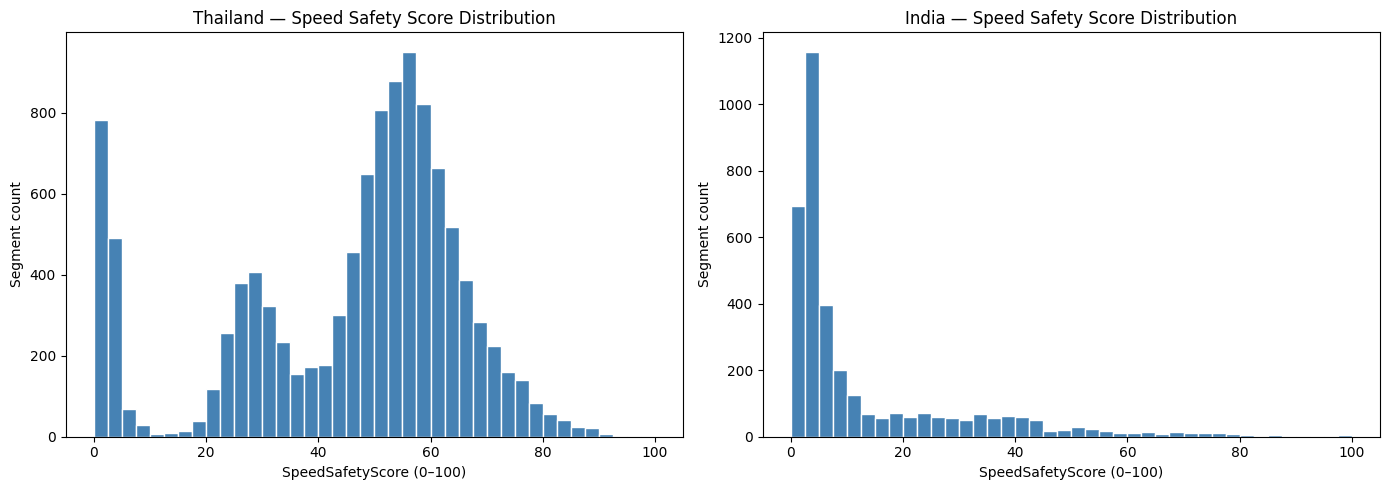

In [8]:
# Score distribution histograms
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, gdf) in zip(axes, [('Thailand', thai_gdf), ('India', india_gdf)]):
    ax.hist(gdf['SpeedSafetyScore'], bins=40, color='steelblue', edgecolor='white')
    ax.set_title(f'{name} — Speed Safety Score Distribution')
    ax.set_xlabel('SpeedSafetyScore (0–100)')
    ax.set_ylabel('Segment count')

plt.tight_layout()
plt.show()

## Interactive Maps

In [9]:
tier_colours = {
    'Low':      '#2ecc71',
    'Medium':   '#f39c12',
    'High':     '#e74c3c',
    'Critical': '#8e44ad',
}

legend_html = """
<div style="position:fixed;bottom:40px;left:40px;z-index:1000;
            background:white;padding:15px;border-radius:8px;
            box-shadow:2px 2px 6px rgba(0,0,0,.3);font-family:Arial;">
  <b style="font-size:14px;">Speed Safety Score</b><br><br>
  <span style="color:#8e44ad;">&#9646;</span> Critical (75–100)<br>
  <span style="color:#e74c3c;">&#9646;</span> High (50–75)<br>
  <span style="color:#f39c12;">&#9646;</span> Medium (25–50)<br>
  <span style="color:#2ecc71;">&#9646;</span> Low (0–25)<br>
</div>
"""

def build_map(gdf, road_name_col=None):
    bounds = gdf.total_bounds
    center = [(bounds[1] + bounds[3]) / 2, (bounds[0] + bounds[2]) / 2]
    m = folium.Map(location=center, zoom_start=6, tiles='CartoDB dark_matter')

    for _, row in gdf.iterrows():
        tier   = str(row['PriorityTier'])
        colour = tier_colours.get(tier, '#888888')
        road   = row[road_name_col] if road_name_col and road_name_col in gdf.columns else 'N/A'

        popup_html = f"""
        <div style="font-family:Arial;width:280px;">
          <h4 style="color:{colour};margin-bottom:8px;">{tier} Priority</h4>
          <table style="width:100%;font-size:12px;">
            <tr><td><b>Road</b></td><td>{road}</td></tr>
            <tr><td><b>Class</b></td><td>{row['RoadClass']} — {row['LandUse']}</td></tr>
            <tr><td><b>Speed Limit</b></td><td>{row['SpeedLimit']} km/h</td></tr>
            <tr><td><b>F85 Speed</b></td><td>{round(row['F85thPercentileSpeed'],1)} km/h</td></tr>
            <tr><td><b>Median Speed</b></td><td>{round(row['MedianSpeed'],1)} km/h</td></tr>
            <tr><td><b>Safe Threshold</b></td><td>{row['SafeThreshold']} km/h</td></tr>
            <tr><td><b>Safety Score</b></td><td>{round(row['SpeedSafetyScore'],1)} / 100</td></tr>
            <tr><td><b>Data Quality</b></td><td>{row['PlausibilityFlag']}</td></tr>
          </table>
        </div>"""

        folium.GeoJson(
            row['geometry'],
            style_function=lambda _f, c=colour: {'color': c, 'weight': 2, 'opacity': 0.8},
            popup=folium.Popup(popup_html, max_width=300)
        ).add_to(m)

    m.get_root().html.add_child(folium.Element(legend_html))
    return m

In [10]:
thai_map = build_map(thai_gdf, road_name_col='english_ro')
thai_map.save('maps/thailand_speed_safety_map.html')

In [11]:
india_map = build_map(india_gdf)
india_map.save('maps/india_speed_safety_map.html')

### Save the scores

In [12]:
# Save as CSV (tabular)
thai_gdf.to_csv('data/thai_safety_score.csv', index=False)
india_gdf.to_csv('data/india_safety_score.csv', index=False)